<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Minimal_Weinberg_Mixing_Photon_Z_Bridge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Minimal Weinberg-Mixing / Photon–Z Bridge

This notebook tests the next algebraic step after the ECSM minimal \(SU(2)_L\) and hypercharge/electric-charge bridge notebooks:

\[
(Q_0,Q_{\rm ch})_L
\rightarrow
SU(2)_L
\rightarrow
SU(2)_L\times U(1)_Y
\rightarrow
Q_{\rm ECSM}=T_3+\frac{Y}{2}
\rightarrow
A/Z\text{-like neutral-mode splitting}.
\]

The field-mode question is:

Can a branch-phase / hypercharge-like field \(B\) and a neutral closure-imbalance field \(W^3\) coherently rotate into one massless photon-like mode \(A\) and one mass-locked \(Z\)-like mode?

We test the minimal neutral mass-locking matrix in the field basis \((B,W^3)\):

\[
M^2
=
m_0^2
\begin{pmatrix}
g'^2 & -gg'\\
-gg' & g^2
\end{pmatrix}.
\]

Target result:

\[
m_A^2=0,
\qquad
m_Z^2=m_0^2(g^2+g'^2).
\]

This is not a full electroweak derivation. It is a minimal ECSM algebraic test of whether branch-phase and closure-imbalance neutral modes can split into one massless photon-like survivor and one \(Z\)-like mass-locked mode.

## ECSM interpretation

\[
B_\mu
=
\text{branch-phase / hypercharge-like field},
\]

\[
W^3_\mu
=
\text{neutral closure-imbalance field},
\]

\[
A_\mu
=
\text{surviving long-range coherent charge mode},
\]

\[
Z_\mu
=
\text{mass-locked neutral closure mode}.
\]

In [13]:
# CELL 1 — Imports and output directory

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json

OUT = Path("ecsm_weinberg_mixing_photon_z_bridge_out")
OUT.mkdir(exist_ok=True)

np.set_printoptions(precision=8, suppress=True)

print("Output directory:", OUT.resolve())

Output directory: /content/ecsm_weinberg_mixing_photon_z_bridge_out


In [14]:
# CELL 2 — Define minimal neutral mass-locking matrix and rotation

def mass_matrix(g, gp, m0=1.0):
    return (m0**2) * np.array([[gp**2, -g*gp],
                               [-g*gp, g**2]], dtype=float)

def theta_weinberg(g, gp):
    return np.arctan2(gp, g)

def rotation_matrix(theta):
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([[c, s],
                     [-s, c]], dtype=float)

# Illustrative couplings, not precision electroweak inputs
g = 0.65
gp = 0.35
m0 = 1.0

M2 = mass_matrix(g, gp, m0)
theta = theta_weinberg(g, gp)
R = rotation_matrix(theta)

print("g =", g)
print("g' =", gp)
print("theta =", theta)
print("sin(theta) =", np.sin(theta))
print("cos(theta) =", np.cos(theta))
print("\nM^2 in basis (B, W3):")
print(M2)
print("\nRotation matrix R mapping (B,W3)->(A,Z):")
print(R)

g = 0.65
g' = 0.35
theta = 0.4939413689195812
sin(theta) = 0.4740998230350174
cos(theta) = 0.8804710999221753

M^2 in basis (B, W3):
[[ 0.1225 -0.2275]
 [-0.2275  0.4225]]

Rotation matrix R mapping (B,W3)->(A,Z):
[[ 0.8804711   0.47409982]
 [-0.47409982  0.8804711 ]]


In [15]:
# CELL 3 — Diagonalize mass matrix and verify zero photon-like eigenvalue

eigvals, eigvecs = np.linalg.eigh(M2)
idx = np.argsort(eigvals)
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

expected_mA2 = 0.0
expected_mZ2 = m0**2 * (g**2 + gp**2)

diag_df = pd.DataFrame([
    {"mode": "A_like", "numerical_m2": eigvals[0], "expected_m2": expected_mA2, "abs_error": abs(eigvals[0] - expected_mA2)},
    {"mode": "Z_like", "numerical_m2": eigvals[1], "expected_m2": expected_mZ2, "abs_error": abs(eigvals[1] - expected_mZ2)}
])

display(diag_df)
print("Eigenvectors columns in (B, W3) basis:")
print(eigvecs)

diag_df.to_csv(OUT / "neutral_mass_eigenvalues.csv", index=False)
print("Saved:", OUT / "neutral_mass_eigenvalues.csv")

,mode,numerical_m2,expected_m2,abs_error
0,A_like,1.387779e-17,0.000,1.387779e-17
1,Z_like,5.450000e-01,0.545,0.000000e+00


Eigenvectors columns in (B, W3) basis:
[[-0.8804711  -0.47409982]
 [-0.47409982  0.8804711 ]]
Saved: ecsm_weinberg_mixing_photon_z_bridge_out/neutral_mass_eigenvalues.csv


In [16]:
# CELL 4 — Verify rotation diagonalizes the mass matrix

M2_rot = R @ M2 @ R.T

rot_df = pd.DataFrame(M2_rot, index=["A_like", "Z_like"], columns=["A_like", "Z_like"])
display(rot_df)

offdiag_error = abs(M2_rot[0,1]) + abs(M2_rot[1,0])
diag_error = abs(M2_rot[0,0] - expected_mA2) + abs(M2_rot[1,1] - expected_mZ2)

rotation_summary = {
    "offdiag_error": float(offdiag_error),
    "diag_error": float(diag_error),
    "M2_rot": M2_rot.tolist()
}
rotation_summary

,A_like,Z_like
A_like,1.970453e-17,1.368292e-17
Z_like,1.628432e-17,5.450000e-01


{'offdiag_error': 2.996723424719269e-17,
 'diag_error': 1.9704526371962096e-17,
 'M2_rot': [[1.9704526371962096e-17, 1.3682919083964726e-17],
  [1.6284315163227964e-17, 0.545]]}

In [17]:
# CELL 5 — Coupling identities and electric charge relation

sin_th = np.sin(theta)
cos_th = np.cos(theta)

e_from_g = g * sin_th
e_from_gp = gp * cos_th
e_expected = (g * gp) / np.sqrt(g**2 + gp**2)

coupling_df = pd.DataFrame([
    {"quantity": "g sin(theta)", "value": e_from_g},
    {"quantity": "g' cos(theta)", "value": e_from_gp},
    {"quantity": "g g' / sqrt(g^2+g'^2)", "value": e_expected},
    {"quantity": "|g sin - g' cos|", "value": abs(e_from_g - e_from_gp)}
])

display(coupling_df)

coupling_summary = {
    "e_from_g_sin": float(e_from_g),
    "e_from_gp_cos": float(e_from_gp),
    "e_expected": float(e_expected),
    "identity_error": float(abs(e_from_g - e_from_gp))
}

coupling_df.to_csv(OUT / "electric_charge_coupling_identity.csv", index=False)
print("Saved:", OUT / "electric_charge_coupling_identity.csv")

,quantity,value
0,g sin(theta),0.308165
1,g' cos(theta),0.308165
2,g g' / sqrt(g^2+g'^2),0.308165
3,|g sin - g' cos|,0.000000


Saved: ecsm_weinberg_mixing_photon_z_bridge_out/electric_charge_coupling_identity.csv


In [18]:
# CELL 6 — Scan coupling ratios and verify massless A-like mode

ratios = np.linspace(0.05, 3.0, 200)
scan_rows = []

g_fixed = 1.0
m0_fixed = 1.0

for r in ratios:
    gp_scan = r * g_fixed
    M = mass_matrix(g_fixed, gp_scan, m0_fixed)
    vals = np.sort(np.linalg.eigvalsh(M))
    th = theta_weinberg(g_fixed, gp_scan)
    e_val = g_fixed * np.sin(th)
    scan_rows.append({
        "gp_over_g": r,
        "theta": th,
        "sin2_theta": np.sin(th)**2,
        "mA2": vals[0],
        "mZ2": vals[1],
        "expected_mZ2": g_fixed**2 + gp_scan**2,
        "mA2_abs": abs(vals[0]),
        "mZ2_error": abs(vals[1] - (g_fixed**2 + gp_scan**2)),
        "e": e_val
    })

scan_df = pd.DataFrame(scan_rows)
display(scan_df.head())
display(scan_df.tail())

scan_df.to_csv(OUT / "coupling_ratio_scan_photon_z_modes.csv", index=False)
print("Saved:", OUT / "coupling_ratio_scan_photon_z_modes.csv")

,gp_over_g,theta,sin2_theta,mA2,mZ2,expected_mZ2,mA2_abs,mZ2_error,e
0,0.050000,0.049958,0.002494,4.336809e-19,1.002500,1.002500,4.336809e-19,0.000000e+00,0.049938
1,0.064824,0.064734,0.004185,0.000000e+00,1.004202,1.004202,0.000000e+00,0.000000e+00,0.064688
2,0.079648,0.079480,0.006304,8.673617e-19,1.006344,1.006344,8.673617e-19,0.000000e+00,0.079397
3,0.094472,0.094193,0.008846,-1.734723e-18,1.008925,1.008925,1.734723e-18,2.220446e-16,0.094054
4,0.109296,0.108864,0.011805,0.000000e+00,1.011946,1.011946,0.000000e+00,0.000000e+00,0.108649


,gp_over_g,theta,sin2_theta,mA2,mZ2,expected_mZ2,mA2_abs,mZ2_error,e
195,2.940704,1.243009,0.896349,-1.110223e-16,9.647737,9.647737,1.110223e-16,0.0,0.946757
196,2.955528,1.244538,0.897279,1.110223e-16,9.735144,9.735144,1.110223e-16,0.0,0.947248
197,2.970352,1.246054,0.898198,-1.110223e-16,9.822990,9.822990,1.110223e-16,0.0,0.947733
198,2.985176,1.247557,0.899105,0.000000e+00,9.911275,9.911275,0.000000e+00,0.0,0.948211
199,3.000000,1.249046,0.900000,1.110223e-16,10.000000,10.000000,1.110223e-16,0.0,0.948683


Saved: ecsm_weinberg_mixing_photon_z_bridge_out/coupling_ratio_scan_photon_z_modes.csv


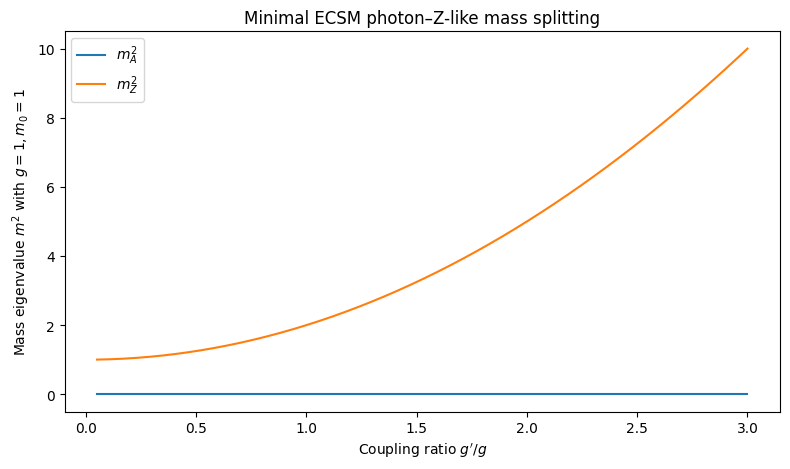

Saved: ecsm_weinberg_mixing_photon_z_bridge_out/fig1_mass_eigenvalues_vs_coupling_ratio.png


In [19]:
# CELL 7 — Plot mass eigenvalues versus coupling ratio

plt.figure(figsize=(8, 4.8))
plt.plot(scan_df["gp_over_g"], scan_df["mA2"], label=r"$m_A^2$")
plt.plot(scan_df["gp_over_g"], scan_df["mZ2"], label=r"$m_Z^2$")
plt.xlabel(r"Coupling ratio $g'/g$")
plt.ylabel(r"Mass eigenvalue $m^2$ with $g=1,m_0=1$")
plt.title("Minimal ECSM photon–Z-like mass splitting")
plt.legend()
plt.tight_layout()

fig_path = OUT / "fig1_mass_eigenvalues_vs_coupling_ratio.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)

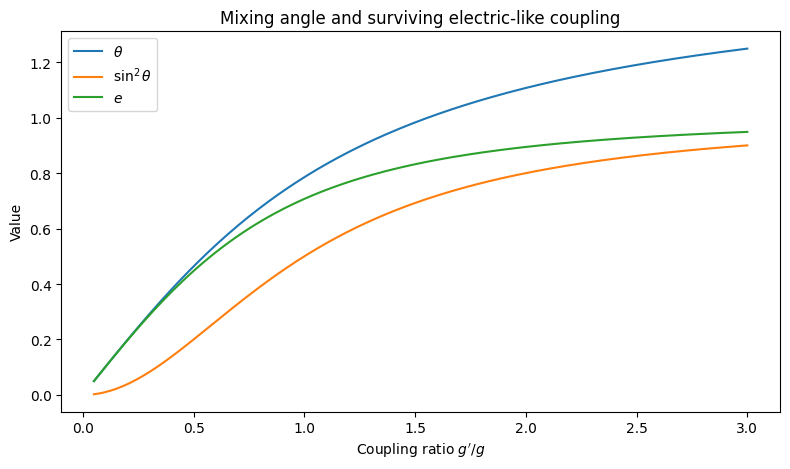

Saved: ecsm_weinberg_mixing_photon_z_bridge_out/fig2_mixing_angle_and_e_vs_ratio.png


In [20]:
# CELL 8 — Plot mixing angle and electric coupling versus ratio

plt.figure(figsize=(8, 4.8))
plt.plot(scan_df["gp_over_g"], scan_df["theta"], label=r"$\theta$")
plt.plot(scan_df["gp_over_g"], scan_df["sin2_theta"], label=r"$\sin^2\theta$")
plt.plot(scan_df["gp_over_g"], scan_df["e"], label=r"$e$")
plt.xlabel(r"Coupling ratio $g'/g$")
plt.ylabel("Value")
plt.title("Mixing angle and surviving electric-like coupling")
plt.legend()
plt.tight_layout()

fig_path = OUT / "fig2_mixing_angle_and_e_vs_ratio.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)

In [21]:
# CELL 9 — Finite-response deformation of neutral mass-locking matrix

DeltaM = np.array([[0.10, 0.03],
                   [0.03, -0.08]], dtype=float)

M_base = mass_matrix(g, gp, m0)

def M2_chi(chi):
    return M_base + (1-chi) * DeltaM

chi_vals = np.linspace(0, 1, 101)
chi_rows = []

for chi in chi_vals:
    Mchi = M2_chi(chi)
    vals = np.sort(np.linalg.eigvalsh(Mchi))
    chi_rows.append({
        "chi": chi,
        "mA2_like": vals[0],
        "mZ2_like": vals[1],
        "mA2_abs_error_from_zero": abs(vals[0]),
        "mZ2_error_from_coherent": abs(vals[1] - expected_mZ2)
    })

chi_df = pd.DataFrame(chi_rows)
display(chi_df.head())
display(chi_df.tail())

chi_df.to_csv(OUT / "chi_deformed_photon_z_mass_recovery.csv", index=False)
print("Saved:", OUT / "chi_deformed_photon_z_mass_recovery.csv")

,chi,mA2_like,mZ2_like,mA2_abs_error_from_zero,mZ2_error_from_coherent
0,0.00,0.076087,0.488913,0.076087,0.056087
1,0.01,0.075437,0.489363,0.075437,0.055637
2,0.02,0.074784,0.489816,0.074784,0.055184
3,0.03,0.074128,0.490272,0.074128,0.054728
4,0.04,0.073470,0.490730,0.073470,0.054270


,chi,mA2_like,mZ2_like,mA2_abs_error_from_zero,mZ2_error_from_coherent
96,0.96,3.373285e-03,0.542427,3.373285e-03,0.002573
97,0.97,2.531892e-03,0.543068,2.531892e-03,0.001932
98,0.98,1.689207e-03,0.543711,1.689207e-03,0.001289
99,0.99,8.452392e-04,0.544355,8.452392e-04,0.000645
100,1.00,1.387779e-17,0.545000,1.387779e-17,0.000000


Saved: ecsm_weinberg_mixing_photon_z_bridge_out/chi_deformed_photon_z_mass_recovery.csv


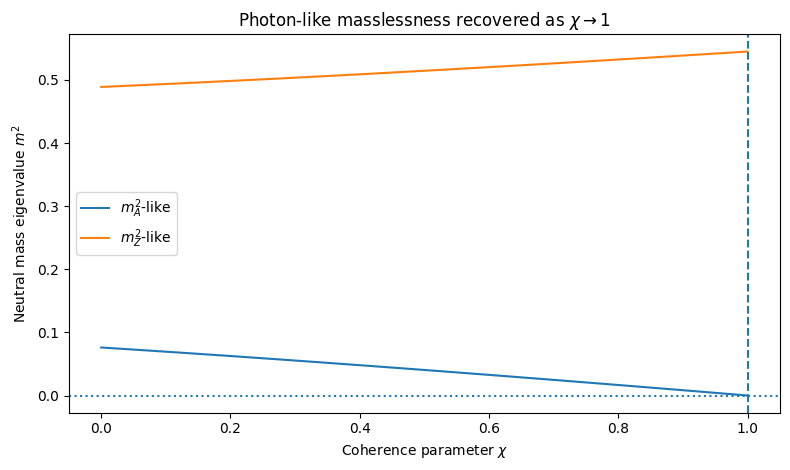

Saved: ecsm_weinberg_mixing_photon_z_bridge_out/fig3_chi_recovery_photon_z_modes.png


In [22]:
# CELL 10 — Plot chi recovery of photon-like masslessness

plt.figure(figsize=(8, 4.8))
plt.plot(chi_df["chi"], chi_df["mA2_like"], label=r"$m_A^2$-like")
plt.plot(chi_df["chi"], chi_df["mZ2_like"], label=r"$m_Z^2$-like")
plt.axhline(0, linestyle=":")
plt.axvline(1, linestyle="--")
plt.xlabel(r"Coherence parameter $\chi$")
plt.ylabel(r"Neutral mass eigenvalue $m^2$")
plt.title(r"Photon-like masslessness recovered as $\chi\rightarrow1$")
plt.legend()
plt.tight_layout()

fig_path = OUT / "fig3_chi_recovery_photon_z_modes.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)

In [23]:
# CELL 11 — Final summary and verdict

tol = 1e-10

pass_eigenvalues = (
    abs(float(eigvals[0]) - expected_mA2) < tol
    and abs(float(eigvals[1]) - expected_mZ2) < tol
)

pass_rotation = (
    rotation_summary["offdiag_error"] < tol
    and rotation_summary["diag_error"] < tol
)

pass_coupling_identity = coupling_summary["identity_error"] < tol

pass_scan = (
    scan_df["mA2_abs"].max() < 1e-10
    and scan_df["mZ2_error"].max() < 1e-10
)

final_label = (
    "PASS_MINIMAL_PHOTON_Z_MIXING_BRIDGE"
    if pass_eigenvalues and pass_rotation and pass_coupling_identity and pass_scan
    else "FAIL_MINIMAL_PHOTON_Z_MIXING_BRIDGE"
)

summary = {
    "run_label": "ECSM_minimal_weinberg_mixing_photon_z_bridge",
    "basis": ["B_branch_phase_hypercharge_like", "W3_neutral_closure_imbalance"],
    "g": g,
    "g_prime": gp,
    "m0": m0,
    "theta": float(theta),
    "sin_theta": float(np.sin(theta)),
    "cos_theta": float(np.cos(theta)),
    "mass_eigenvalues": {
        "mA2_numerical": float(eigvals[0]),
        "mA2_expected": expected_mA2,
        "mZ2_numerical": float(eigvals[1]),
        "mZ2_expected": float(expected_mZ2),
        "pass": pass_eigenvalues
    },
    "rotation_diagonalization": {
        "offdiag_error": rotation_summary["offdiag_error"],
        "diag_error": rotation_summary["diag_error"],
        "pass": pass_rotation
    },
    "electric_coupling_identity": {
        **coupling_summary,
        "pass": pass_coupling_identity
    },
    "coupling_ratio_scan": {
        "max_mA2_abs": float(scan_df["mA2_abs"].max()),
        "max_mZ2_error": float(scan_df["mZ2_error"].max()),
        "pass": pass_scan
    },
    "interpretation": "Branch-phase B and neutral closure-imbalance W3 coherently rotate into a massless photon-like survivor A and a mass-locked neutral Z-like mode.",
    "final_label": final_label
}

summary

{'run_label': 'ECSM_minimal_weinberg_mixing_photon_z_bridge',
 'basis': ['B_branch_phase_hypercharge_like', 'W3_neutral_closure_imbalance'],
 'g': 0.65,
 'g_prime': 0.35,
 'm0': 1.0,
 'theta': 0.4939413689195812,
 'sin_theta': 0.4740998230350174,
 'cos_theta': 0.8804710999221753,
 'mass_eigenvalues': {'mA2_numerical': 1.3877787807814457e-17,
  'mA2_expected': 0.0,
  'mZ2_numerical': 0.545,
  'mZ2_expected': 0.545,
  'pass': True},
 'rotation_diagonalization': {'offdiag_error': 2.996723424719269e-17,
  'diag_error': 1.9704526371962096e-17,
  'pass': True},
 'electric_coupling_identity': {'e_from_g_sin': 0.30816488497276134,
  'e_from_gp_cos': 0.30816488497276134,
  'e_expected': 0.3081648849727613,
  'identity_error': 0.0,
  'pass': True},
 'coupling_ratio_scan': {'max_mA2_abs': 2.220446049250313e-16,
  'max_mZ2_error': 8.881784197001252e-16,
  'pass': True},
 'interpretation': 'Branch-phase B and neutral closure-imbalance W3 coherently rotate into a massless photon-like survivor A and 

In [24]:
# CELL 12 — Save output files

with open(OUT / "final_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved outputs:")
for p in sorted(OUT.iterdir()):
    print(" -", p)

Saved outputs:
 - ecsm_weinberg_mixing_photon_z_bridge_out/chi_deformed_photon_z_mass_recovery.csv
 - ecsm_weinberg_mixing_photon_z_bridge_out/coupling_ratio_scan_photon_z_modes.csv
 - ecsm_weinberg_mixing_photon_z_bridge_out/electric_charge_coupling_identity.csv
 - ecsm_weinberg_mixing_photon_z_bridge_out/fig1_mass_eigenvalues_vs_coupling_ratio.png
 - ecsm_weinberg_mixing_photon_z_bridge_out/fig2_mixing_angle_and_e_vs_ratio.png
 - ecsm_weinberg_mixing_photon_z_bridge_out/fig3_chi_recovery_photon_z_modes.png
 - ecsm_weinberg_mixing_photon_z_bridge_out/final_summary.json
 - ecsm_weinberg_mixing_photon_z_bridge_out/neutral_mass_eigenvalues.csv


# Paper-grade interpretation

The notebook supports the following narrow statement:

A branch-phase / hypercharge-like field \(B\) and a neutral closure-imbalance field \(W^3\) can be combined through a coherent rotation

\[
\begin{pmatrix}
A\\
Z
\end{pmatrix}
=
\begin{pmatrix}
\cos\theta & \sin\theta\\
-\sin\theta & \cos\theta
\end{pmatrix}
\begin{pmatrix}
B\\
W^3
\end{pmatrix},
\]

where

\[
\tan\theta=\frac{g'}{g}.
\]

The minimal neutral mass-locking matrix

\[
M^2
=
m_0^2
\begin{pmatrix}
g'^2 & -gg'\\
-gg' & g^2
\end{pmatrix}
\]

has one massless eigenmode and one massive eigenmode:

\[
m_A^2=0,
\qquad
m_Z^2=m_0^2(g^2+g'^2).
\]

ECSM interpretation:

\[
A_\mu
=
\text{surviving long-range coherent charge mode},
\]

\[
Z_\mu
=
\text{mass-locked neutral closure mode}.
\]

This does not derive the full electroweak theory, the Weinberg-angle value, \(W/Z\) masses, Higgs dynamics, weak cross sections, or precision observables. It establishes a minimal photon--\(Z\)-like mixing bridge for the ECSM weak-sector programme.